In [36]:
from cProfile import label

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import alpha
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures


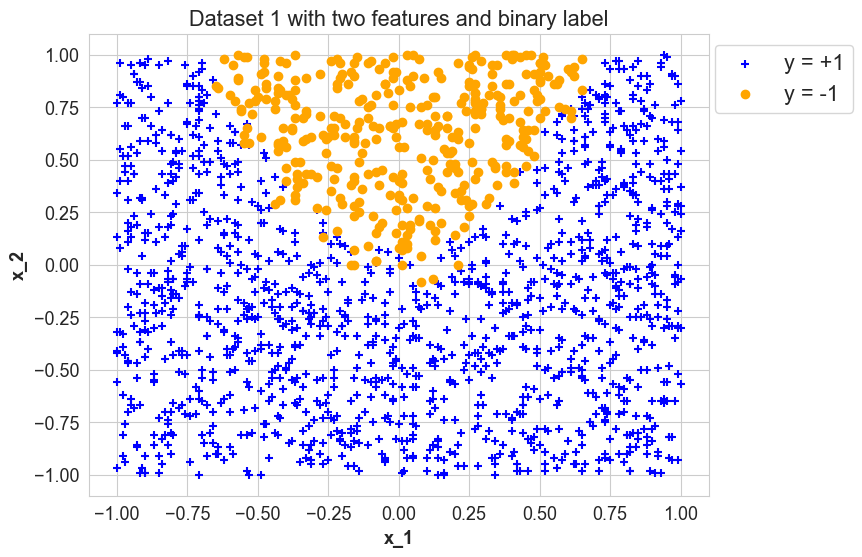

In [37]:
df = pd.read_csv('week4_data1.csv', skiprows=1, names=['x1', 'x2', 'y'])

plt.figure(figsize=[8, 6])
plt.scatter(
    y=df[df['y'] == 1]['x2'],
    x=df[df['y'] == 1]['x1'],
    color='blue',
    marker='+',
    label='y = +1'
)
plt.scatter(
    x=df[df['y'] == -1]['x1'],
    y=df[df['y'] == -1]['x2'],
    color='orange',
    marker='o',
    label='y = -1'
)

plt.title('Dataset 1 with two features and binary label')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelweight': 'bold',
    'axes.edgecolor': '#333333',
})

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize='large')
plt.show()

# Logistic Regression

In [38]:
X = df[['x1', 'x2']].to_numpy()
y = df['y'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

c_values = [0.01, 0.1, 1, 2, 5, 10, 20]
degree_values = [1, 2, 3, 4, 5, 6, 7, 8]

scores_by_c_degree = {}
for c in c_values:
    lr_model = LogisticRegression(penalty='l2', C=c)
    for d in degree_values:
        pf = PolynomialFeatures(degree=d, include_bias=False)
        x_train_pl = pf.fit_transform(x_train)
        scores = cross_val_score(lr_model, x_train_pl, y_train, cv=5, scoring='roc_auc')
        scores_by_c_degree[(c, d)] = scores

degree_scores = [v for (c, _), v in scores_by_c_degree.items() if c == 1]
c_scores = [v for (_, d), v in scores_by_c_degree.items() if d == 2]

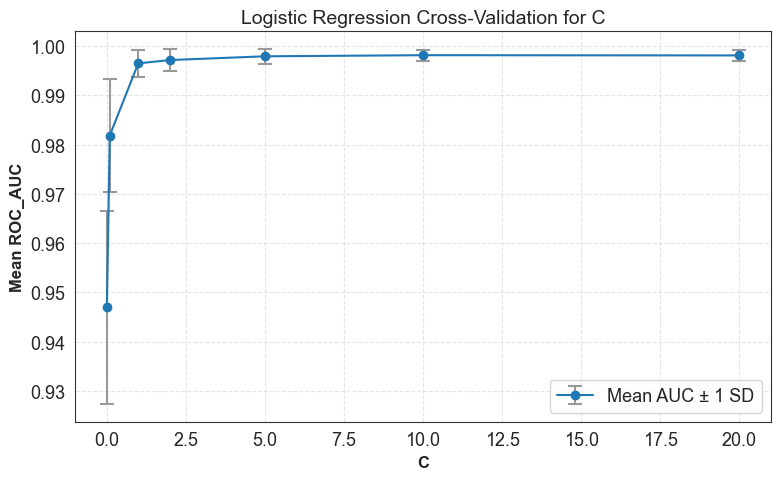

In [39]:
means = [scores.mean() for scores in c_scores]
stds = [scores.std() for scores in c_scores]

plt.figure(figsize=(8, 5))
main_color = '#1f77b4'
error_color = '#999999'
plt.errorbar(
    c_values, means, yerr=stds,
    fmt='o-',
    capsize=5,
    elinewidth=1.5, capthick=1.5,
    color=main_color, ecolor=error_color,
    label='Mean AUC ± 1 SD'
)

plt.xlabel('C', fontsize=12)
plt.ylabel('Mean ROC_AUC', fontsize=12)
plt.title('Logistic Regression Cross-Validation for C', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(loc='best')
plt.show()

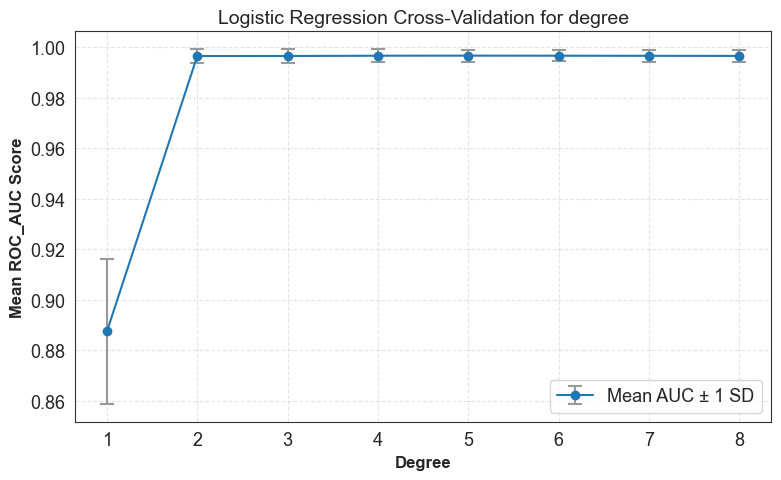

In [40]:
means = [scores.mean() for scores in degree_scores]
stds = [scores.std() for scores in degree_scores]

plt.figure(figsize=(8, 5))
main_color = '#1f77b4'
error_color = '#999999'
plt.errorbar(
    degree_values, means, yerr=stds,
    fmt='o-',
    capsize=5,
    elinewidth=1.5, capthick=1.5,
    color=main_color, ecolor=error_color,
    label='Mean AUC ± 1 SD'
)

plt.xlabel('Degree', fontsize=12)
plt.ylabel('Mean ROC_AUC Score', fontsize=12)
plt.title('Logistic Regression Cross-Validation for degree', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(loc='best')
plt.show()

I select C = 2 and Degree = 3

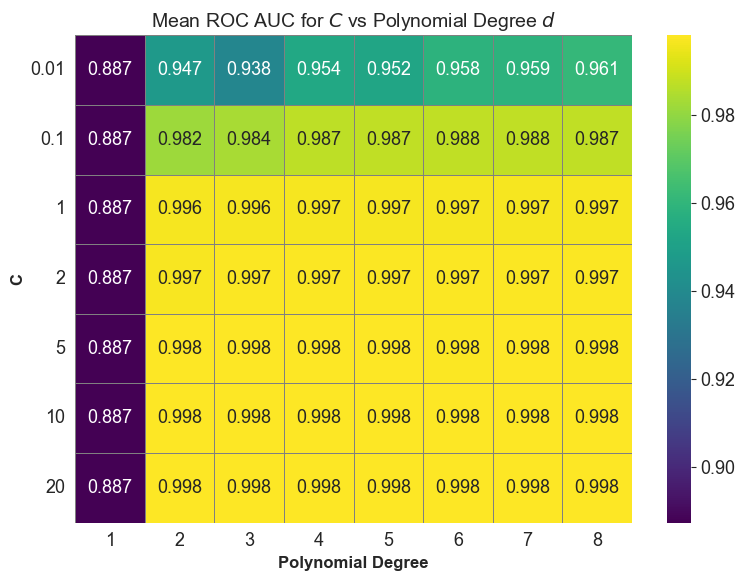

In [41]:
mean_by_c_degree = {key: scores.mean() for key, scores in scores_by_c_degree.items()}
grid = np.array(list(mean_by_c_degree.values())).reshape(len(c_values), len(degree_values))

plt.figure(figsize=(8, 6))
sns.heatmap(grid, annot=True, fmt=".3f", cmap="viridis", cbar=True, linewidths=0.5, linecolor='gray')

plt.xlabel("Polynomial Degree", fontsize=12)
plt.ylabel("C", fontsize=12)
plt.title("Mean ROC AUC for $C$ vs Polynomial Degree $d$", fontsize=14)
plt.xticks(ticks=np.arange(len(degree_values)) + 0.5, labels=degree_values, rotation=0)
plt.yticks(ticks=np.arange(len(c_values)) + 0.5, labels=c_values, rotation=0)
plt.tight_layout()
plt.show()

In [42]:
x_train_pl = PolynomialFeatures(degree=3, include_bias=False).fit_transform(x_train)
x_test_pl = PolynomialFeatures(degree=3, include_bias=False).fit_transform(x_test)

lr_model = LogisticRegression(C=5, penalty='l2')
lr_model.fit(x_train_pl, y_train)
lr_predictions = lr_model.predict(x_test_pl)
intercept, coefficients = lr_model.intercept_[0], lr_model.coef_[0]

print(f'intercept: {intercept}, weights: {coefficients}')
print(f'AUC-Score: {roc_auc_score(y_test, lr_predictions)}')
print(f'F1-Score: {f1_score(y_test, lr_predictions)}')

intercept: 0.5915721786084166, weights: [ 0.39281403 -9.37546777 14.25839044 -0.10059385 -0.39785092  0.0535824
  6.3922731  -0.55953144 -0.72500394]
AUC-Score: 0.9815595933376595
F1-Score: 0.9868173258003766


# K-Nearest-Neighbors

In [43]:
k_values = [1, 3, 10, 15, 20, 30, 50, 70, 100]
scores_by_k = {}
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k, weights='distance')
    auc_scores = cross_val_score(knn_model, x_train, y_train, cv=5, scoring='roc_auc')
    scores_by_k[k] = np.array(auc_scores)

means = [scores.mean() for scores in scores_by_k.values()]
stds = [scores.std() for scores in scores_by_k.values()]

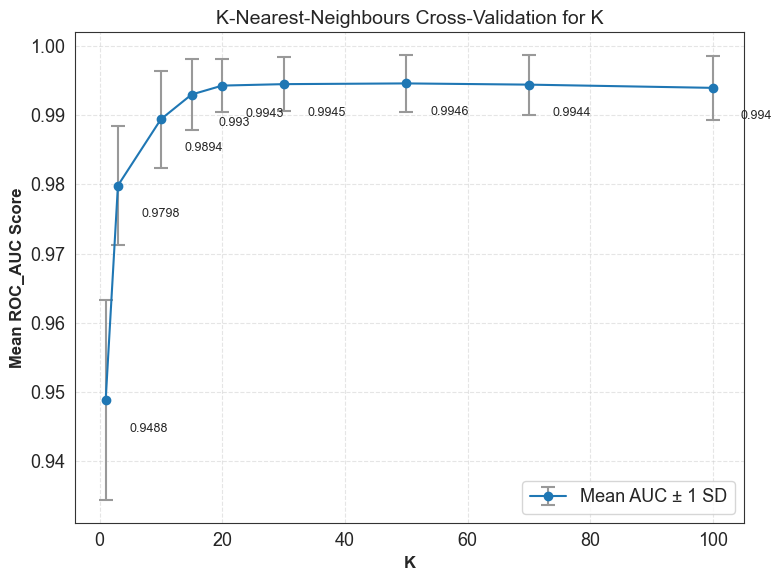

In [44]:
plt.figure(figsize=(8, 6))
main_color = '#1f77b4'
error_color = '#999999'
plt.errorbar(
    k_values, means, yerr=stds,
    fmt='o-',
    capsize=5,
    elinewidth=1.5, capthick=1.5,
    color=main_color, ecolor=error_color,
    label='Mean AUC ± 1 SD'
)

for x_cor, y_cor in zip(k_values, means):
    plt.text(x_cor + 7, y_cor - 0.005, f'{round(y_cor, 4)}', ha='center', va='bottom', fontsize=9)

plt.xlabel('K', fontsize=12)
plt.ylabel('Mean ROC_AUC Score', fontsize=12)
plt.title('K-Nearest-Neighbours Cross-Validation for K', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(loc='best')
plt.show()

# Comparision

In [45]:
pf = PolynomialFeatures(degree=2, include_bias=False)
x_train_pl = pf.fit_transform(x_train)
x_test_pl = pf.fit_transform(x_test)

lr_model = LogisticRegression(C=5, penalty='l2')
lr_model.fit(x_train_pl, y_train)
lr_predictions = lr_model.predict(x_test_pl)
intercept, coefficients = lr_model.intercept_[0], lr_model.coef_[0]

print(f'intercept: {intercept}, weights: {coefficients}\n')
print(f'Logistic Regression AUC-Score: {roc_auc_score(y_test, lr_predictions)}')
print(f'Logistic Regression F1-Score: {f1_score(y_test, lr_predictions)}')

intercept: 0.44037839532901896, weights: [ 0.46511056 -9.1868898  16.49046984 -0.53311881  0.68195408]

Logistic Regression AUC-Score: 0.9815595933376595
Logistic Regression F1-Score: 0.9868173258003766


In [46]:
knn_model = KNeighborsClassifier(n_neighbors=50, weights='distance')
knn_model.fit(x_train, y_train)
knn_predictions = knn_model.predict(x_test)

print(f'KNN AUC-Score: {roc_auc_score(y_test, knn_predictions)}')
print(f'KNN F1-Score: {f1_score(y_test, knn_predictions)}')


KNN AUC-Score: 0.9707981829980532
KNN F1-Score: 0.9869158878504672


In [47]:
mc_model = DummyClassifier(strategy='most_frequent')
mc_model.fit(x_train, y_train)
mc_predictions = mc_model.predict(x_test)

print(f'Most Common AUC-Score: {roc_auc_score(y_test, mc_predictions)}')
print(f'Most Common F1-Score: {f1_score(y_test, mc_predictions)}\n')

random_model = DummyClassifier(strategy='uniform')
random_model.fit(x_train, y_train)
random_predictions = random_model.predict(x_test)

print(f'Random Classifier AUC-Score: {roc_auc_score(y_test, random_predictions)}')
print(f'Random Classifier F1-Score: {f1_score(y_test, random_predictions)}')

Most Common AUC-Score: 0.5
Most Common F1-Score: 0.8859504132231405

Random Classifier AUC-Score: 0.47442137140385027
Random Classifier F1-Score: 0.5977011494252874


[[ 32  37]
 [138 130]]


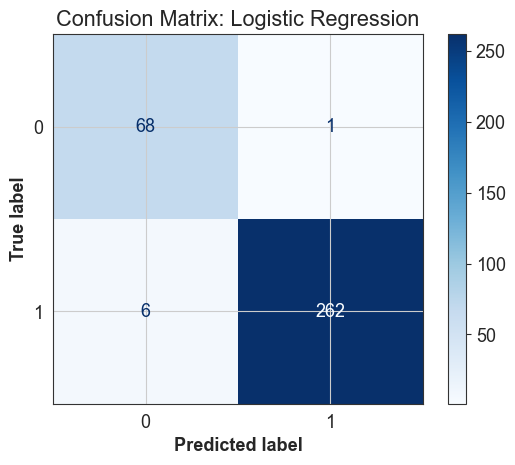

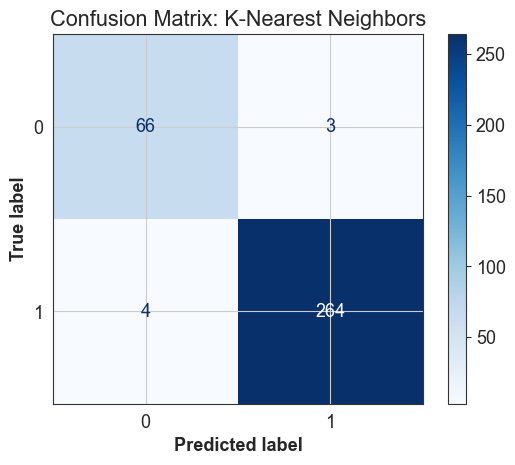

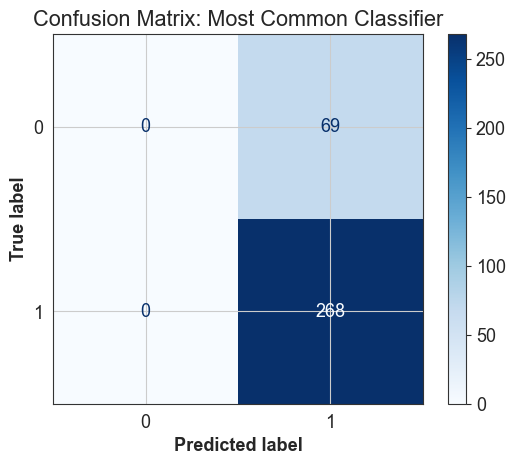

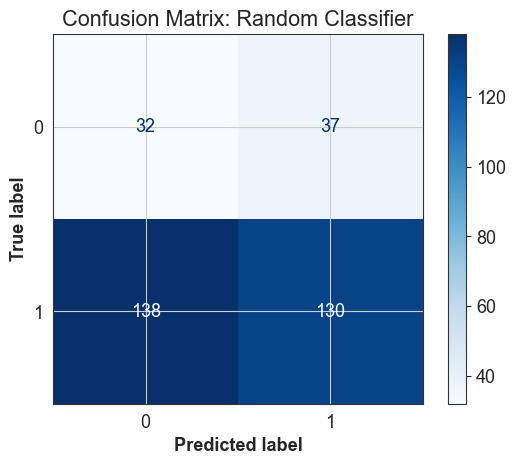

In [48]:
lr_cm = confusion_matrix(y_test, lr_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")

knn_cm = confusion_matrix(y_test, knn_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=knn_cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: K-Nearest Neighbors")

mc_cm = confusion_matrix(y_test, mc_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=mc_cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Most Common Classifier")

random_cm = confusion_matrix(y_test, random_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=random_cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Random Classifier")
print(random_cm)

plt.show()

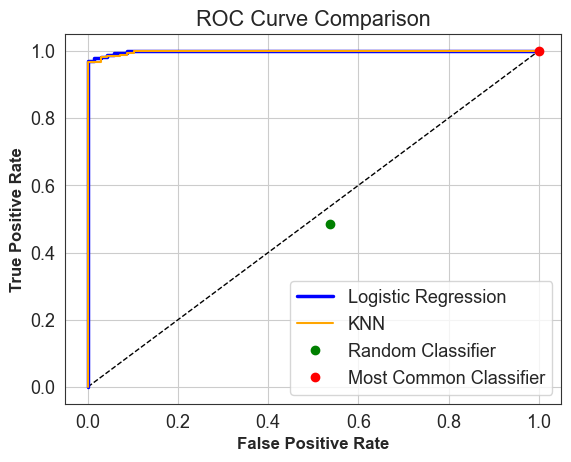

In [49]:
plt.plot([0, 1], [0, 1], 'k--', lw=1)

lr_proba = lr_model.predict_proba(x_test_pl)[:, 1]
knn_proba = knn_model.predict_proba(x_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_proba)
plt.plot(lr_fpr, lr_tpr, color='blue', lw=2.5, label='Logistic Regression')
plt.plot(knn_fpr, knn_tpr, color='orange', lw=1.5, label='KNN')

TN, FP, FN, TP = random_cm.ravel()
tpr_random = TP / (TP + FN)
fpr_random = FP / (FP + TN)
plt.plot(fpr_random, tpr_random, 'go', label='Random Classifier')

TN, FP, FN, TP = mc_cm.ravel()
tpr_mc = TP / (TP + FN)
fpr_mc = FP / (FP + TN)
plt.plot(fpr_mc, tpr_mc, 'ro', label='Most Common Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='best')
plt.title('ROC Curve Comparison')

plt.show()

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


/var/folders/nh/yh9mg2mx39ng5t5l9bd8r2400000gn/T/ipykernel_8533/250643377.py:11: UserWarning: The following kwargs were not used by contour: 'color', 'label'
  plt.contour(x1_coords, x2_coords, grid_pred, alpha=1, color='black', label='Decision Boundary')


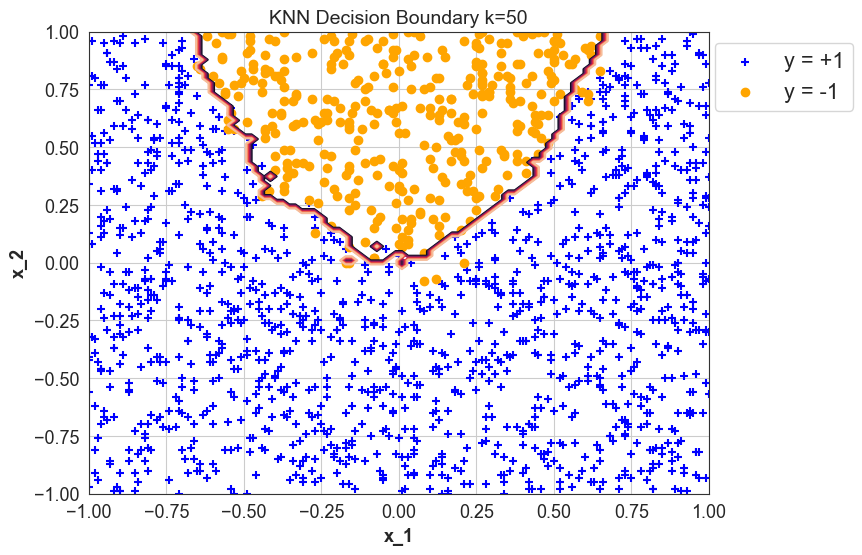

In [50]:
grid_range = np.linspace(-1, 1, 100)
x1_coords, x2_coords = np.meshgrid(grid_range, grid_range)

grid_pred = knn_model.predict(np.column_stack([x1_coords.ravel(), x2_coords.ravel()]))
grid_pred = grid_pred.reshape(x1_coords.shape)

plt.figure(figsize=(8, 6))

print(grid_pred)

plt.contour(x1_coords, x2_coords, grid_pred, alpha=1, color='black', label='Decision Boundary')

plt.scatter(y=df[df['y'] == 1]['x2'], x=df[df['y'] == 1]['x1'], color='blue', marker='+', label='y = +1')
plt.scatter(x=df[df['y'] == -1]['x1'], y=df[df['y'] == -1]['x2'], color='orange', marker='o', label='y = -1')

plt.title(f'KNN Decision Boundary k=50', fontsize=14)
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelweight': 'bold',
    'axes.edgecolor': '#333333',
})
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize='large')
plt.show()